# Validación lógica de la función de probabilidad de reclutamiento $P_i$

**Tesina:** Factores de riesgo, protección e índice de probabilidad de reclutamiento de niñas, niños y adolescentes: una propuesta de modelación matemática para el caso mexicano

**Autora:** María Alejandra Galicia Almaraz  
**Institución:** Instituto Tecnológico Autónomo de México (ITAM)  
**Directora:** Dra. Mayra Núñez  
**Año:** 2026

---

## Objetivo de este notebook

Este notebook tiene un propósito exclusivamente de **validación lógica**: verificar que el índice de probabilidad propuesto se comporte de manera coherente con la teoría, sin datos reales de reclutamiento. Se analizan:

1. El comportamiento de $P_i$ en escenarios extremos y representativos
2. La monotonía de $P_i$ respecto a factores de riesgo y protección
3. El efecto de acumulación capturado por el término $R_i(1+n_i)$
4. La sensibilidad al parámetro de contexto $\alpha$

---

## La ecuación propuesta

$$P_i = \frac{e^{\Sigma_i}}{1 + e^{\Sigma_i}} = \sigma(\Sigma_i)$$

donde el **índice de vulnerabilidad individualizado** $\Sigma_i$ es:

$$\Sigma_i = \alpha + \underbrace{R_i \cdot (1 + n_i)}_{\text{término de riesgo acumulado}} - \underbrace{\frac{\sum_{k=1}^{3} w_k^P p_{ik}}{1 + R_i}}_{\text{término de protección con efectividad decreciente}}$$

con:

| Símbolo | Definición |
|---------|-----------|
| $f_{ik} \in \{0,1\}$ | Indicador de presencia del factor de riesgo $k$ en el adolescente $i$ |
| $p_{ik} \in \{0,1\}$ | Indicador de presencia del factor protector $k$ en el adolescente $i$ |
| $R_i = \sum_{k=1}^{7} w_k^F f_{ik}$ | Carga de riesgo ponderada (AHP) |
| $n_i = \sum_{k=1}^{7} f_{ik}$ | Número de factores de riesgo activos |
| $w_k^F$ | Peso AHP del factor de riesgo $k$ (media geométrica grupal) |
| $w_k^P$ | Peso AHP del factor protector $k$ (media geométrica grupal) |
| $\alpha \in \mathbb{R}$ | Parámetro de contexto criminal (no calibrado empíricamente) |


## 0. Librerías

In [1]:
# Librerías estándar de análisis numérico y visualización
import numpy as np                        # álgebra lineal y operaciones vectoriales
import matplotlib.pyplot as plt           # gráficas
import matplotlib.gridspec as gridspec    # layout de subplots
import pandas as pd                       # tablas y DataFrames
import warnings
warnings.filterwarnings('ignore')

# Configuración general de estilo para las gráficas
plt.rcParams.update({
    'font.family':     'serif',
    'font.size':       10,
    'axes.titlesize':  11,
    'axes.labelsize':  10,
    'figure.facecolor':'white',
    'axes.facecolor':  '#f9f9f9',
    'axes.grid':       True,
    'grid.alpha':      0.4,
})

print("✓ Librerías cargadas correctamente.")


✓ Librerías cargadas correctamente.


## 1. Pesos AHP

Los pesos que se utilizan son los **vectores de pesos agregados por media geométrica** 
derivados en el Capítulo 3 (Cuadros 3.34 y 3.35). La media geométrica es el método 
recomendado en la literatura de AHP grupal (Aczél & Saaty, 1983) porque es consistente 
con la naturaleza multiplicativa de la escala de Saaty y preserva la propiedad de reciprocidad.

Por construcción del AHP: $\sum_{k=1}^{7} w_k^F = 1$ y $\sum_{k=1}^{3} w_k^P = 1$.  
Esto garantiza que $R_i \in [0,1]$ y que la carga protectora también vive en $[0,1]$.


In [2]:
# ── Pesos AHP de factores de RIESGO (Cuadro 3.34, media geométrica) ──────────
# Orden: F1, F2, F3, F4, F5, F6, F7
W_F = np.array([
    0.2038,   # F1: Violencia en el entorno inmediato
    0.0956,   # F2: Precariedad económica familiar
    0.0957,   # F3: Deserción escolar
    0.0412,   # F4: Identificación con narcocultura
    0.3596,   # F5: Proximidad al crimen organizado  ← peso más alto
    0.1334,   # F6: Uso de sustancias
    0.0707,   # F7: Ausencia de pertenencia prosocial
])

# ── Pesos AHP de factores de PROTECCIÓN (Cuadro 3.35, media geométrica) ──────
# Orden: P1, P2, P3
W_P = np.array([
    0.5596,   # P1: Red de apoyo adulto activa        ← peso más alto
    0.1431,   # P2: Expectativas de futuro
    0.2973,   # P3: Participación en actividad estructurada
])

# Etiquetas para visualizaciones
NOMBRES_F = ["F1 Violencia\nentorno",
             "F2 Precariedad\neconómica",
             "F3 Deserción\nescolar",
             "F4 Narco-\ncultura",
             "F5 Proximidad\ncrimen",
             "F6 Uso de\nsustancias",
             "F7 Ausencia\npertenencia"]

NOMBRES_P = ["P1 Red apoyo\nadulto",
             "P2 Expectativas\nfuturo",
             "P3 Actividad\nestructurada"]

# Verificación: los pesos deben sumar exactamente 1 en cada bloque
print(f"Suma pesos de riesgo:     {W_F.sum():.4f}  (debe ser 1.0000)")
print(f"Suma pesos de protección: {W_P.sum():.4f}  (debe ser 1.0000)")
print()

# Tabla de pesos
df_pesos = pd.DataFrame({
    "Factor": [f"F{k+1}" for k in range(7)],
    "Descripción": ["Violencia en el entorno", "Precariedad económica familiar",
                    "Deserción escolar", "Identificación con narcocultura",
                    "Proximidad al crimen organizado", "Uso de sustancias",
                    "Ausencia de pertenencia prosocial"],
    "Peso AHP (med. geom.)": W_F
})
df_pesos_p = pd.DataFrame({
    "Factor": [f"P{k+1}" for k in range(3)],
    "Descripción": ["Red de apoyo adulto activa", "Expectativas de futuro",
                    "Participación en actividad estructurada"],
    "Peso AHP (med. geom.)": W_P
})
print("Factores de riesgo:")
display(df_pesos)
print("\nFactores de protección:")
display(df_pesos_p)


Suma pesos de riesgo:     1.0000  (debe ser 1.0000)
Suma pesos de protección: 1.0000  (debe ser 1.0000)

Factores de riesgo:


,Factor,Descripción,Peso AHP (med. geom.)
0,F1,Violencia en el entorno,0.2038
1,F2,Precariedad económica familiar,0.0956
2,F3,Deserción escolar,0.0957
3,F4,Identificación con narcocultura,0.0412
4,F5,Proximidad al crimen organizado,0.3596
5,F6,Uso de sustancias,0.1334
6,F7,Ausencia de pertenencia prosocial,0.0707



Factores de protección:


,Factor,Descripción,Peso AHP (med. geom.)
0,P1,Red de apoyo adulto activa,0.5596
1,P2,Expectativas de futuro,0.1431
2,P3,Participación en actividad estructurada,0.2973


## 2. Implementación de la función $P_i$

Se implementan tres funciones principales:

- `sigma(x)`: la función logística estándar $\sigma(x) = \frac{e^x}{1+e^x}$
- `compute_Sigma(f, p, alpha)`: calcula el índice $\Sigma_i$
- `compute_Pi(f, p, alpha)`: calcula $P_i = \sigma(\Sigma_i)$
- `subterminos(f, p, alpha)`: devuelve todos los componentes intermedios para análisis detallado


In [3]:
def sigma(x):
    """
    Función logística estándar: sigma(x) = e^x / (1 + e^x).
    
    Mapea cualquier valor real x ∈ ℝ al intervalo abierto (0, 1).
    Es monótona creciente: sigma'(x) = sigma(x) * (1 - sigma(x)) > 0 para todo x.
    
    Heredada de Prieto-Curiel et al. (2025) via la Proposición 4.1 de la tesina:
    bajo el supuesto de ruido Gumbel independiente, la probabilidad de que el
    término de error supere cualquier umbral tiene exactamente esta forma.
    """
    return 1.0 / (1.0 + np.exp(-x))


def compute_Sigma(f, p, alpha=0.0):
    """
    Calcula el índice de vulnerabilidad individualizado Sigma_i.
    
    Parámetros
    ----------
    f     : array de longitud 7, binario {0,1} — factores de riesgo activos
    p     : array de longitud 3, binario {0,1} — factores de protección activos
    alpha : float — parámetro de contexto criminal (default=0)
    
    Retorna
    -------
    Sigma_i : float
        Sigma_i = alpha + R_i*(1+n_i) - sum_P/(1+R_i)
    
    Componentes
    -----------
    R_i   = W_F @ f          → carga de riesgo ponderada, R_i ∈ [0,1]
    n_i   = sum(f)           → número de factores de riesgo activos, n_i ∈ {0,...,7}
    sum_P = W_P @ p          → carga protectora ponderada, sum_P ∈ [0,1]
    
    Término de riesgo:    R_i * (1 + n_i)
        → captura acumulación: cada factor adicional amplifica el peso de todos los demás.
          Cuando n_i=0: contribución = R_i (sin amplificación).
          Cuando n_i=k: contribución = R_i * (k+1).
    
    Término de protección: sum_P / (1 + R_i)
        → captura efectividad decreciente: los protectores pierden fuerza cuando
          la carga de riesgo R_i es alta.
          Cuando R_i≈0: protectores operan casi a peso completo (divisor ≈ 1).
          Cuando R_i≈1: protectores reducen su efectividad a la mitad (divisor = 2).
    """
    f     = np.asarray(f, dtype=float)
    p     = np.asarray(p, dtype=float)
    R_i   = W_F @ f            # carga de riesgo ponderada
    n_i   = f.sum()            # conteo de factores activos
    sum_P = W_P @ p            # carga protectora ponderada
    return alpha + R_i * (1 + n_i) - sum_P / (1 + R_i)


def compute_Pi(f, p, alpha=0.0):
    """
    Calcula la probabilidad de reclutamiento P_i = sigma(Sigma_i).
    
    P_i ∈ (0,1) por propiedades de la función logística.
    P_i es monótona creciente en Sigma_i.
    """
    return sigma(compute_Sigma(f, p, alpha))


def subterminos(f, p, alpha=0.0):
    """
    Calcula y devuelve todos los componentes intermedios de Sigma_i.
    Útil para análisis detallado de cómo contribuye cada término.
    
    Retorna un diccionario con:
        R_i        : carga de riesgo ponderada
        n_i        : número de factores de riesgo activos
        sum_P      : carga protectora ponderada
        termino_R  : R_i * (1 + n_i)   — contribución de riesgo al índice
        termino_P  : sum_P / (1 + R_i) — contribución de protección al índice
        Sigma      : índice de vulnerabilidad completo
        Pi         : probabilidad de reclutamiento
    """
    f      = np.asarray(f, dtype=float)
    p      = np.asarray(p, dtype=float)
    R_i    = W_F @ f
    n_i    = f.sum()
    sum_P  = W_P @ p
    term_R = R_i * (1 + n_i)
    term_P = sum_P / (1 + R_i)
    Sigma  = alpha + term_R - term_P
    Pi     = sigma(Sigma)
    return dict(R_i=round(R_i,4), n_i=int(n_i), sum_P=round(sum_P,4),
                termino_R=round(term_R,4), termino_P=round(term_P,4),
                Sigma=round(Sigma,4), Pi=round(Pi,4))


print("✓ Funciones definidas correctamente.")
print()
# Verificación rápida con un perfil de ejemplo
f_ejemplo = np.array([1,0,0,0,1,0,0])   # F1 y F5 activos
p_ejemplo = np.array([1,0,0])           # P1 activo
st = subterminos(f_ejemplo, p_ejemplo)
print("Ejemplo: F1+F5 activos, P1 activo")
for k, v in st.items():
    print(f"  {k:12s} = {v}")


✓ Funciones definidas correctamente.

Ejemplo: F1+F5 activos, P1 activo
  R_i          = 0.5634
  n_i          = 2
  sum_P        = 0.5596
  termino_R    = 1.6902
  termino_P    = 0.3579
  Sigma        = 1.3323
  Pi           = 0.7912


## 3. Análisis de escenarios

Se evalúan 12 escenarios que cubren el espectro completo de perfiles posibles: 
desde el caso sin ningún factor activo hasta el máximo riesgo con y sin protectores. 

**¿Qué esperamos lógicamente?**
- E1 (sin nada): P_i cercano a 0.5 cuando α=0 (contexto neutro)
- E2 (solo protectores): P_i debe bajar respecto a E1
- E10 (máximo riesgo, sin protectores): P_i debe estar cerca de 1
- E11 vs E10: con todos los protectores activos, P_i debe bajar, pero poco si el riesgo es muy alto (efectividad decreciente)


In [4]:
# Definición de los 12 escenarios
# Cada escenario es una tupla (f, p) donde:
#   f = vector binario de longitud 7 (factores de riesgo)
#   p = vector binario de longitud 3 (factores de protección)

ALPHA = 0.0   # Parámetro de contexto fijo en 0 para el análisis base
              # α=0 representa un contexto criminal "neutro"
              # α>0 representa mayor presencia/actividad del crimen organizado
              # α<0 representa menor presencia institucional del crimen

escenarios = {
    "E1: Sin factores activos":
        (np.zeros(7), np.zeros(3)),

    "E2: Solo protectores (todos)":
        (np.zeros(7), np.ones(3)),

    "E3: Solo riesgo leve (F4 narcocultura)":
        # F4 es el factor de menor peso (0.0412)
        (np.array([0,0,0,1,0,0,0]), np.zeros(3)),

    "E4: Solo riesgo mayor (F5 proximidad)":
        # F5 es el factor de mayor peso (0.3596)
        (np.array([0,0,0,0,1,0,0]), np.zeros(3)),

    "E5: F5 + todos los protectores":
        # ¿Los protectores compensan al factor más importante?
        (np.array([0,0,0,0,1,0,0]), np.ones(3)),

    "E6: Riesgo moderado (F1+F2+F3) sin protectores":
        # Tres factores de peso medio activados simultáneamente
        (np.array([1,1,1,0,0,0,0]), np.zeros(3)),

    "E7: Riesgo moderado (F1+F2+F3) + todos protectores":
        # ¿Los protectores amortiguan el riesgo moderado?
        (np.array([1,1,1,0,0,0,0]), np.ones(3)),

    "E8: Alto riesgo (F1+F2+F5+F6) sin protectores":
        # Cuatro factores incluyendo el de mayor peso
        (np.array([1,1,0,0,1,1,0]), np.zeros(3)),

    "E9: Alto riesgo (F1+F2+F5+F6) + todos protectores":
        # Con alto riesgo, ¿cuánto ayudan los protectores?
        (np.array([1,1,0,0,1,1,0]), np.ones(3)),

    "E10: Máximo riesgo (todos F) sin protectores":
        # Caso extremo superior: todos los factores de riesgo activos
        (np.ones(7), np.zeros(3)),

    "E11: Máximo riesgo (todos F) + todos protectores":
        # Caso extremo: máximo riesgo Y máxima protección simultáneos
        (np.ones(7), np.ones(3)),

    "E12: Sin riesgo + protector más fuerte (P1)":
        # ¿Cuánto protege P1 (red de apoyo adulto) por sí solo?
        (np.zeros(7), np.array([1,0,0])),
}

# ── Cálculo y tabla de resultados ────────────────────────────────────────────
filas = []
for nombre, (f, p) in escenarios.items():
    st = subterminos(f, p, alpha=ALPHA)
    filas.append({
        "Escenario":               nombre,
        "R_i":                     st["R_i"],
        "n_i":                     st["n_i"],
        "R_i·(1+n_i)":            st["termino_R"],
        "ΣP/(1+R_i)":             st["termino_P"],
        "Σ_i":                     st["Sigma"],
        "P_i":                     st["Pi"],
    })

df_escenarios = pd.DataFrame(filas)
print("Tabla de resultados por escenario (α = 0):")
display(df_escenarios)


Tabla de resultados por escenario (α = 0):


,Escenario,R_i,n_i,R_i·(1+n_i),ΣP/(1+R_i),Σ_i,P_i
0,E1: Sin factores activos,0.0000,0,0.0000,0.0000,0.0000,0.5000
1,E2: Solo protectores (todos),0.0000,0,0.0000,1.0000,-1.0000,0.2689
2,E3: Solo riesgo leve (F4 narcocultura),0.0412,1,0.0824,0.0000,0.0824,0.5206
3,E4: Solo riesgo mayor (F5 proximidad),0.3596,1,0.7192,0.0000,0.7192,0.6724
4,E5: F5 + todos los protectores,0.3596,1,0.7192,0.7355,-0.0163,0.4959
5,E6: Riesgo moderado (F1+F2+F3) sin protectores,0.3951,3,1.5804,0.0000,1.5804,0.8293
6,E7: Riesgo moderado (F1+F2+F3) + todos protect...,0.3951,3,1.5804,0.7168,0.8636,0.7034
7,E8: Alto riesgo (F1+F2+F5+F6) sin protectores,0.7924,4,3.9620,0.0000,3.9620,0.9813
8,E9: Alto riesgo (F1+F2+F5+F6) + todos protectores,0.7924,4,3.9620,0.5579,3.4041,0.9678
9,E10: Máximo riesgo (todos F) sin protectores,1.0000,7,8.0000,0.0000,8.0000,0.9997


### Figura 1: $P_i$ por escenario

Visualización del valor de $P_i$ para cada uno de los 12 escenarios. 
El color indica el nivel de riesgo: verde (bajo), naranja (medio), rojo (alto).


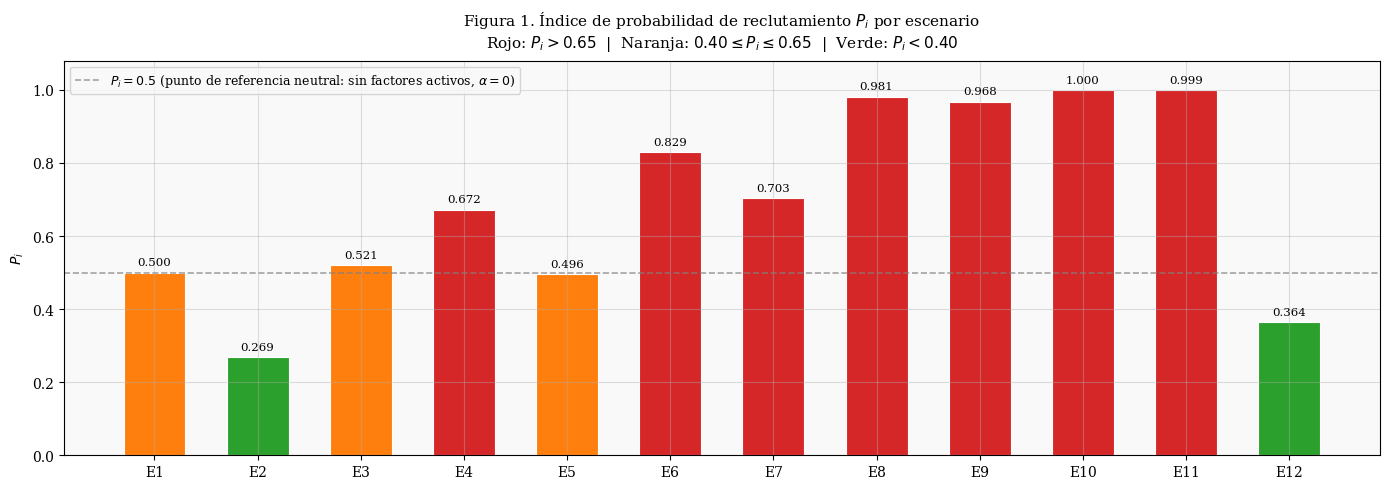

✓ Figura 1 guardada.


In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
nombres_cortos = [f"E{i+1}" for i in range(len(escenarios))]
valores_Pi     = [r["P_i"] for r in filas]

# Color según posición respecto al punto de referencia neutral (0.5)
# Verde:   P_i < 0.4  → claramente por debajo del punto neutral
# Naranja: 0.4 ≤ P_i ≤ 0.65 → zona de transición
# Rojo:    P_i > 0.65  → claramente por encima del punto neutral
colores = ['#d62728' if v > 0.65 else '#ff7f0e' if v >= 0.4 else '#2ca02c'
           for v in valores_Pi]

bars = ax.bar(nombres_cortos, valores_Pi, color=colores,
              edgecolor='white', linewidth=0.8, width=0.6)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2,
           alpha=0.7, label='$P_i = 0.5$ (punto de referencia neutral: sin factores activos, $\\alpha=0$)')
ax.set_ylim(0, 1.08)
ax.set_ylabel("$P_i$")
ax.set_title("Figura 1. Índice de probabilidad de reclutamiento $P_i$ por escenario\n"
             "Rojo: $P_i > 0.65$  |  Naranja: $0.40 \\leq P_i \\leq 0.65$  |  Verde: $P_i < 0.40$",
             pad=10)
ax.legend(fontsize=9)

for bar, val in zip(bars, valores_Pi):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{val:.3f}", ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig("figura1_escenarios.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 1 guardada.")

## 4. Verificación de monotonía

- **Creciente en riesgo:** agregar factores de riesgo nunca debe reducir $P_i$
- **Decreciente en protección:** agregar protectores nunca debe aumentar $P_i$

La verificación se hace de manera exhaustiva: se activan los factores de mayor a menor peso (orden determinista), lo cual representa el peor caso posible.


In [6]:
#  Orden de activación: de mayor a menor peso 
orden_riesgo   = np.argsort(W_F)[::-1]   # índices de F ordenados: F5, F1, F6, ...
orden_protec   = np.argsort(W_P)[::-1]   # índices de P ordenados: P1, P3, P2

# 4a. Monotonía creciente al agregar factores de riesgo
Pi_riesgo  = []
desc_riesgo = []
for k in range(8):
    f = np.zeros(7)
    f[orden_riesgo[:k]] = 1          # activar los k factores de mayor peso
    Pi_riesgo.append(compute_Pi(f, np.zeros(3)))
    factores_activos = [f"F{orden_riesgo[j]+1}" for j in range(k)]
    desc_riesgo.append(", ".join(factores_activos) if factores_activos else "ninguno")

print("Monotonía CRECIENTE — factores de riesgo (sin protectores):")
print(f"{'n_i':>4}  {'Factores activos':<30}  {'P_i':>7}  {'Δ P_i':>8}")
print("-" * 58)
for k in range(8):
    delta = f"+{Pi_riesgo[k]-Pi_riesgo[k-1]:.4f}" if k > 0 else "  —"
    print(f"{k:>4}  {desc_riesgo[k]:<30}  {Pi_riesgo[k]:.4f}  {delta:>8}")

mono_crec = all(Pi_riesgo[i] <= Pi_riesgo[i+1] for i in range(7))
print(f"\n  ¿P_i es monótona creciente al agregar riesgos?  {'SÍ' if mono_crec else 'NO'}")

# 4b. Monotonía decreciente al agregar protectores
Pi_protec  = []
desc_protec = []
f_max = np.ones(7)     # todos los riesgos activos (peor caso para los protectores)
for k in range(4):
    p = np.zeros(3)
    p[orden_protec[:k]] = 1
    Pi_protec.append(compute_Pi(f_max, p))
    prot_activos = [f"P{orden_protec[j]+1}" for j in range(k)]
    desc_protec.append(", ".join(prot_activos) if prot_activos else "ninguno")

print("\nMonotonía DECRECIENTE — protectores (con todos los riesgos activos):")
print(f"{'m':>4}  {'Protectores activos':<25}  {'P_i':>7}  {'Δ P_i':>8}")
print("-" * 52)
for k in range(4):
    delta = f"{Pi_protec[k]-Pi_protec[k-1]:.4f}" if k > 0 else "  —"
    print(f"{k:>4}  {desc_protec[k]:<25}  {Pi_protec[k]:.4f}  {delta:>8}")

mono_decrec = all(Pi_protec[i] >= Pi_protec[i+1] for i in range(3))
print(f"\n  ¿P_i es monótona decreciente al agregar protectores?  {'SÍ' if mono_decrec else  'NO'}")


Monotonía CRECIENTE — factores de riesgo (sin protectores):
 n_i  Factores activos                    P_i     Δ P_i
----------------------------------------------------------
   0  ninguno                         0.5000         —
   1  F5                              0.6724   +0.1724
   2  F5, F1                          0.8443   +0.1718
   3  F5, F1, F6                      0.9420   +0.0977
   4  F5, F1, F6, F3                  0.9813   +0.0394
   5  F5, F1, F6, F3, F2              0.9952   +0.0138
   6  F5, F1, F6, F3, F2, F7          0.9988   +0.0036
   7  F5, F1, F6, F3, F2, F7, F4      0.9997   +0.0009

  ¿P_i es monótona creciente al agregar riesgos?  SÍ

Monotonía DECRECIENTE — protectores (con todos los riesgos activos):
   m  Protectores activos            P_i     Δ P_i
----------------------------------------------------
   0  ninguno                    0.9997         —
   1  P1                         0.9996   -0.0001
   2  P1, P3                     0.9995   -0.0001
   3  P

### Figuras 2 y 3: Monotonía

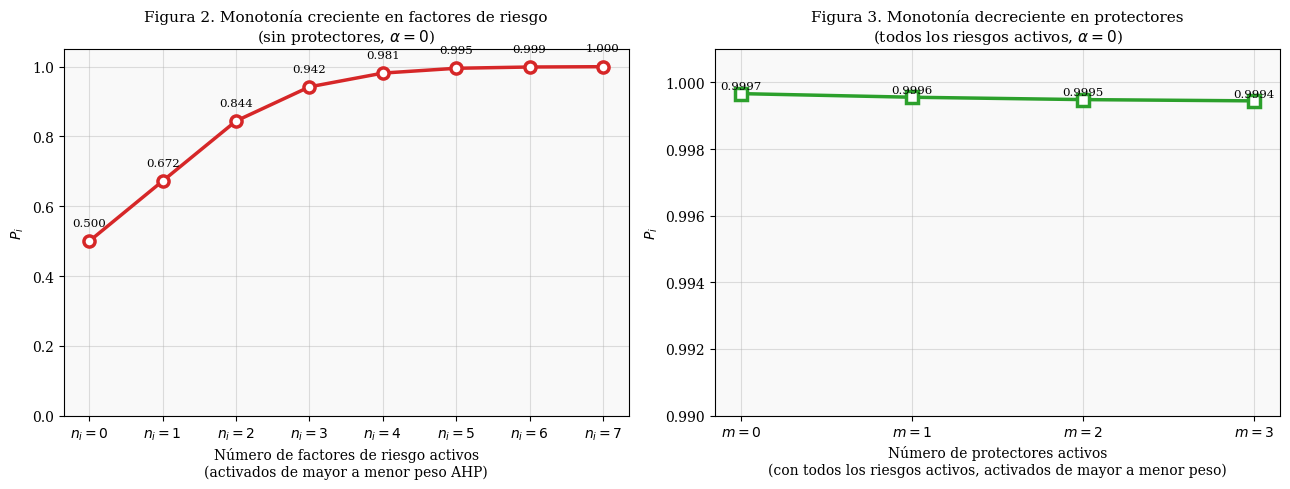

✓ Figuras 2 y 3 guardadas.


In [7]:
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(13, 5))

#  Figura 2: Monotonía creciente 
ax2.plot(range(8), Pi_riesgo, 'o-', color='#d62728', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax2.set_xticks(range(8))
ax2.set_xticklabels([f"$n_i={k}$" for k in range(8)])
ax2.set_xlabel("Número de factores de riesgo activos\n(activados de mayor a menor peso AHP)")
ax2.set_ylabel("$P_i$")
ax2.set_ylim(0, 1.05)
ax2.set_title("Figura 2. Monotonía creciente en factores de riesgo\n"
              "(sin protectores, $\\alpha = 0$)")
for x, y in zip(range(8), Pi_riesgo):
    ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                 xytext=(0, 11), ha='center', fontsize=8.5)

# Figura 3: Monotonía decreciente 
ax3.plot(range(4), Pi_protec, 's-', color='#2ca02c', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax3.set_xticks(range(4))
ax3.set_xticklabels([f"$m={k}$" for k in range(4)])
ax3.set_xlabel("Número de protectores activos\n(con todos los riesgos activos, activados de mayor a menor peso)")
ax3.set_ylabel("$P_i$")
ax3.set_ylim(0.99, 1.001)   # zoom porque la variación es pequeña con riesgo máximo
ax3.set_title("Figura 3. Monotonía decreciente en protectores\n"
              "(todos los riesgos activos, $\\alpha = 0$)")
for x, y in zip(range(4), Pi_protec):
    ax3.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                 xytext=(0, 3), ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig("figura2_3_monotonia.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figuras 2 y 3 guardadas.")


## 5. Efecto de acumulación: $R_i(1+n_i)$ vs suma simple

El término $R_i(1+n_i)$ captura que **la vulnerabilidad no es simplemente aditiva**: 
cada factor de riesgo adicional amplifica el peso de todos los demás. 

Conceptualmente, esto refleja lo que Azaola documenta: un adolescente con seis factores 
activos no está seis veces más vulnerable que uno con solo un factor, sino cualitativamente 
más expuesto porque las vulnerabilidades se refuerzan mutuamente.

Aquí comparamos el término de riesgo propuesto contra lo que produciría una suma simple sin amplificación.


In [8]:
ns         = list(range(1, 8))
R_vals     = []    # carga ponderada R_i
term_prop  = []    # término propuesto: R_i*(1+n_i)
term_adit  = []    # término aditivo simple: R_i (sin amplificación)
ratio_vals = []    # cociente entre propuesto y aditivo

for k in ns:
    f = np.zeros(7)
    f[orden_riesgo[:k]] = 1     # activar los k factores de mayor peso
    R = W_F @ f
    R_vals.append(round(R, 4))
    term_prop.append(round(R * (1 + k), 4))
    term_adit.append(round(R, 4))
    ratio_vals.append(round((1 + k), 2))    # el ratio siempre es (1+n_i)

# Tabla comparativa
df_acum = pd.DataFrame({
    "n_i": ns,
    "R_i (carga pond.)":       R_vals,
    "Suma simple R_i":         term_adit,
    "Propuesto R_i·(1+n_i)":  term_prop,
    "Factor de amplificación": [f"{r:.0f}×" for r in ratio_vals],
})
print("Efecto de acumulación: comparación entre suma simple y término propuesto")
display(df_acum)


Efecto de acumulación: comparación entre suma simple y término propuesto


,n_i,R_i (carga pond.),Suma simple R_i,Propuesto R_i·(1+n_i),Factor de amplificación
0,1,0.3596,0.3596,0.7192,2×
1,2,0.5634,0.5634,1.6902,3×
2,3,0.6968,0.6968,2.7872,4×
3,4,0.7925,0.7925,3.9625,5×
4,5,0.8881,0.8881,5.3286,6×
5,6,0.9588,0.9588,6.7116,7×
6,7,1.0000,1.0000,8.0000,8×


### Figura 4: Efecto de acumulación

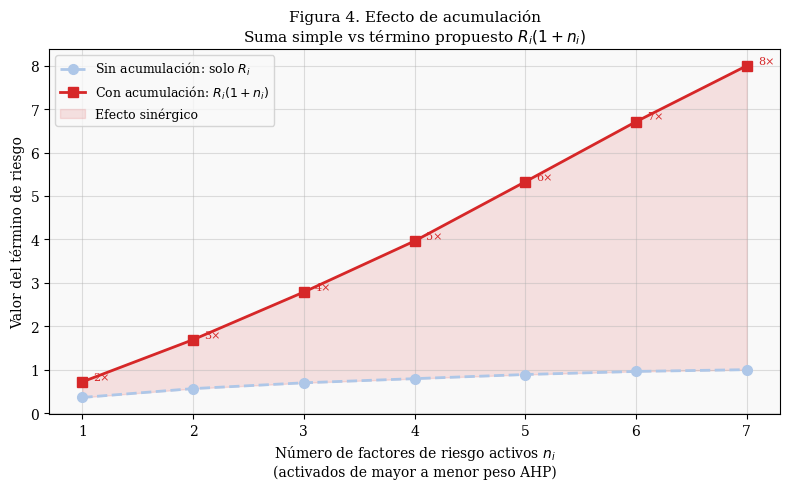

✓ Figura 4 guardada.


In [9]:
fig, ax4 = plt.subplots(figsize=(8, 5))

ax4.plot(ns, term_adit, 'o--', color='#aec7e8', linewidth=2,
         markersize=7, label='Sin acumulación: solo $R_i$')
ax4.plot(ns, term_prop, 's-',  color='#d62728', linewidth=2,
         markersize=7, label='Con acumulación: $R_i(1+n_i)$')
ax4.fill_between(ns, term_adit, term_prop, alpha=0.12, color='#d62728',
                 label='Efecto sinérgico')

ax4.set_xticks(ns)
ax4.set_xlabel("Número de factores de riesgo activos $n_i$\n"
               "(activados de mayor a menor peso AHP)")
ax4.set_ylabel("Valor del término de riesgo")
ax4.set_title("Figura 4. Efecto de acumulación\n"
              "Suma simple vs término propuesto $R_i(1+n_i)$")
ax4.legend(fontsize=9)

# Anotar el factor de amplificación
for x, yp, ya in zip(ns, term_prop, term_adit):
    ax4.annotate(f"{x+1}×", xy=(x, yp),
                 xytext=(x + 0.1, yp + 0.05),
                 fontsize=8, color='#d62728')

plt.tight_layout()
plt.savefig("figura4_acumulacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 4 guardada.")


## 6. Efectividad decreciente de los protectores

El término $\frac{\sum w_k^P p_{ik}}{1 + R_i}$ captura que **los factores de protección 
pierden efectividad conforme aumenta la carga de riesgo**. 

Cuando $R_i \approx 0$: el denominador es $\approx 1$, los protectores operan casi a peso completo.  
Cuando $R_i = 1$ (máximo): el denominador es $2$, los protectores reducen su efectividad a la mitad.

Esto es consistente con lo que Azaola documenta en trayectorias de vulnerabilidad severa: 
incluso la presencia de factores protectores no logra revertir el proceso cuando la acumulación 
de riesgo es muy alta.

Se mostrará cuánto reduce $P_i$ tener **todos los protectores activos**, en función del nivel de riesgo.


In [10]:
# Para cada nivel de riesgo (n_i = 0,...,7), comparar P_i con y sin protectores
niveles  = list(range(8))
Pi_sin_P = []    # sin protectores
Pi_con_P = []    # con todos los protectores
reduccion = []   # diferencia P_i(sin) - P_i(con)

for k in niveles:
    f = np.zeros(7)
    f[orden_riesgo[:k]] = 1
    pi_sin = compute_Pi(f, np.zeros(3))
    pi_con = compute_Pi(f, np.ones(3))
    Pi_sin_P.append(round(pi_sin, 4))
    Pi_con_P.append(round(pi_con, 4))
    reduccion.append(round(pi_sin - pi_con, 4))

df_efec = pd.DataFrame({
    "n_i":                     niveles,
    "P_i (sin protectores)":   Pi_sin_P,
    "P_i (con todos P)":       Pi_con_P,
    "Reducción ΔP_i":          reduccion,
})
print("Efectividad de los protectores según nivel de riesgo acumulado:")
display(df_efec)
print()
print("Interpretación: cuando n_i es alto (mucho riesgo acumulado),")
print("la reducción que producen los protectores es cada vez menor.")
print("Esto refleja la efectividad decreciente capturada en el denominador (1 + R_i).")


Efectividad de los protectores según nivel de riesgo acumulado:


,n_i,P_i (sin protectores),P_i (con todos P),Reducción ΔP_i
0,0,0.5000,0.2689,0.2311
1,1,0.6724,0.4959,0.1765
2,2,0.8443,0.7409,0.1034
3,3,0.9420,0.9001,0.0419
4,4,0.9813,0.9678,0.0135
5,5,0.9952,0.9918,0.0033
6,6,0.9988,0.9980,0.0008
7,7,0.9997,0.9994,0.0002



Interpretación: cuando n_i es alto (mucho riesgo acumulado),
la reducción que producen los protectores es cada vez menor.
Esto refleja la efectividad decreciente capturada en el denominador (1 + R_i).


### Figura 5: Efectividad decreciente de los protectores

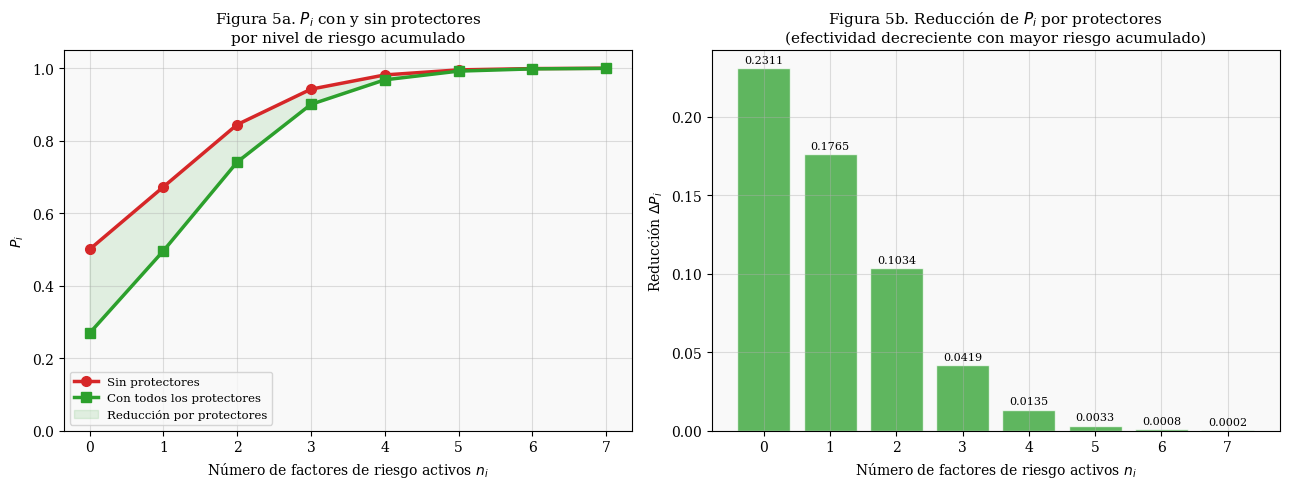

✓ Figura 5 guardada.


In [11]:
fig, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: P_i con y sin protectores
ax5a.plot(niveles, Pi_sin_P, 'o-', color='#d62728', linewidth=2.5,
          markersize=7, label='Sin protectores')
ax5a.plot(niveles, Pi_con_P, 's-', color='#2ca02c', linewidth=2.5,
          markersize=7, label='Con todos los protectores')
ax5a.fill_between(niveles, Pi_con_P, Pi_sin_P, alpha=0.12, color='#2ca02c',
                  label='Reducción por protectores')
ax5a.set_xticks(niveles)
ax5a.set_xlabel("Número de factores de riesgo activos $n_i$")
ax5a.set_ylabel("$P_i$")
ax5a.set_ylim(0, 1.05)
ax5a.set_title("Figura 5a. $P_i$ con y sin protectores\npor nivel de riesgo acumulado")
ax5a.legend(fontsize=8.5)

# Panel derecho: reducción absoluta
ax5b.bar(niveles, reduccion, color='#2ca02c', alpha=0.75, edgecolor='white')
ax5b.set_xticks(niveles)
ax5b.set_xlabel("Número de factores de riesgo activos $n_i$")
ax5b.set_ylabel("Reducción $\\Delta P_i$")
ax5b.set_title("Figura 5b. Reducción de $P_i$ por protectores\n"
               "(efectividad decreciente con mayor riesgo acumulado)")
for x, y in zip(niveles, reduccion):
    ax5b.text(x, y + 0.002, f"{y:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("figura5_efectividad_decreciente.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 5 guardada.")


## 7. Sensibilidad al parámetro $\alpha$

$\alpha$ es el único parámetro libre del modelo. Representa el nivel de actividad y 
presencia del crimen organizado en el contexto del adolescente, independientemente de 
su perfil individual de factores.

- $\alpha = 0$: contexto criminal "neutro" (referencia)
- $\alpha > 0$: mayor presencia/agresividad del crimen organizado en el entorno
- $\alpha < 0$: menor presencia institucional del crimen organizado

Se muestra cómo varía $P_i$ para cuatro perfiles representativos conforme $\alpha$ cambia.


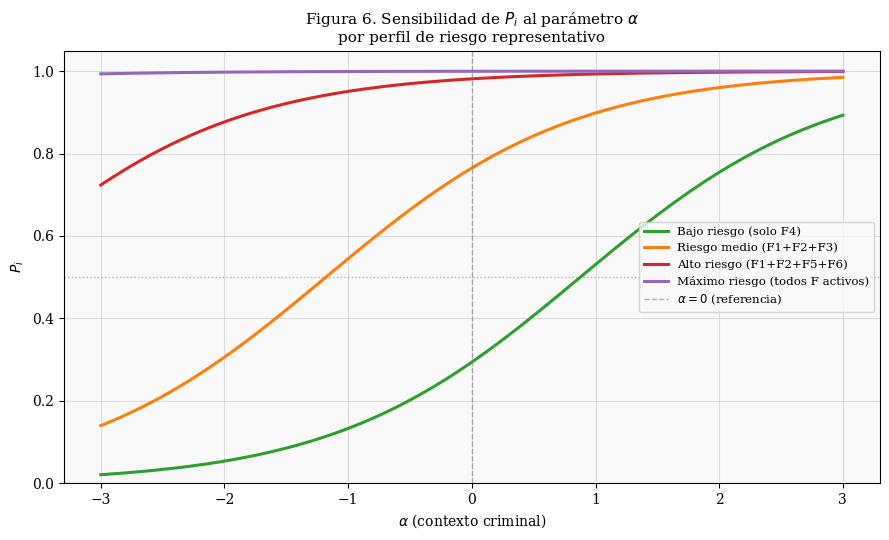

✓ Figura 6 guardada.

Valores de P_i para distintos α (perfil: F1+F2+F5 activos, P1 activo):


,α,P_i
0,-3,0.3315
1,-2,0.5741
2,-1,0.7856
3,0,0.9088
4,1,0.9644
5,2,0.9866
6,3,0.9950


In [12]:
alphas_range = np.linspace(-3, 3, 300)

# Cuatro perfiles representativos
perfiles = {
    "Bajo riesgo (solo F4)":           (np.array([0,0,0,1,0,0,0]), np.ones(3)),
    "Riesgo medio (F1+F2+F3)":         (np.array([1,1,1,0,0,0,0]), np.array([1,0,0])),
    "Alto riesgo (F1+F2+F5+F6)":       (np.array([1,1,0,0,1,1,0]), np.zeros(3)),
    "Máximo riesgo (todos F activos)": (np.ones(7), np.zeros(3)),
}
colores_p = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

fig, ax6 = plt.subplots(figsize=(9, 5.5))

for (label, (f, p)), col in zip(perfiles.items(), colores_p):
    Pi_a = [compute_Pi(f, p, alpha=a) for a in alphas_range]
    ax6.plot(alphas_range, Pi_a, linewidth=2.2, color=col, label=label)

ax6.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6,
            label='$\\alpha = 0$ (referencia)')
ax6.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax6.set_xlabel("$\\alpha$ (contexto criminal)")
ax6.set_ylabel("$P_i$")
ax6.set_title("Figura 6. Sensibilidad de $P_i$ al parámetro $\\alpha$\n"
              "por perfil de riesgo representativo")
ax6.legend(fontsize=8.5, loc='center right')
ax6.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("figura6_sensibilidad_alpha.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 6 guardada.")

# Tabla numérica de sensibilidad
print("\nValores de P_i para distintos α (perfil: F1+F2+F5 activos, P1 activo):")
f_ref = np.array([1,1,0,0,1,0,0])
p_ref = np.array([1,0,0])
df_alpha = pd.DataFrame({
    "α":   [-3, -2, -1, 0, 1, 2, 3],
    "P_i": [round(compute_Pi(f_ref, p_ref, a), 4) for a in [-3,-2,-1,0,1,2,3]]
})
display(df_alpha)


## 8. Resumen de propiedades verificadas

Esta celda consolida los resultados de la validación lógica.


In [13]:
print("=" * 65)
print("RESUMEN DE VALIDACIÓN LÓGICA — P_i")
print("=" * 65)

# Propiedad 1: Acotamiento
todas_Pi = [r["P_i"] for r in filas]
print(f"\n1. ACOTAMIENTO: P_i ∈ (0,1)")
print(f"   Mínimo observado:  {min(todas_Pi):.4f}")
print(f"   Máximo observado:  {max(todas_Pi):.4f}")
print(f"   ✓ Siempre en (0,1) por propiedades de la función logística")

# Propiedad 2: Monotonía creciente
mono_c = all(Pi_riesgo[i] <= Pi_riesgo[i+1] for i in range(7))
print(f"\n2. MONOTONÍA CRECIENTE en factores de riesgo:")
print(f"   {'✓ VERIFICADA' if mono_c else '✗ NO VERIFICADA'}")

# Propiedad 3: Monotonía decreciente
mono_d = all(Pi_protec[i] >= Pi_protec[i+1] for i in range(3))
print(f"\n3. MONOTONÍA DECRECIENTE en factores de protección:")
print(f"   {'✓ VERIFICADA' if mono_d else '✗ NO VERIFICADA'}")

# Propiedad 4: Casos límite
Pi_min_teorico = compute_Pi(np.zeros(7), np.ones(3), alpha=-10)
Pi_max_teorico = compute_Pi(np.ones(7),  np.zeros(3), alpha=10)
print(f"\n4. CASOS LÍMITE:")
print(f"   Sin riesgo, todos protectores, α→-∞: P_i → {Pi_min_teorico:.6f} (→ 0)")
print(f"   Máximo riesgo, sin protectores, α→+∞: P_i → {Pi_max_teorico:.6f} (→ 1)")

# Propiedad 5: Efecto de acumulación
print(f"\n5. EFECTO DE ACUMULACIÓN:")
print(f"   Con n_i=1 factor: R_i*(1+n_i) = 2×R_i")
print(f"   Con n_i=7 factores: R_i*(1+n_i) = 8×R_i")
print(f"   ✓ La vulnerabilidad crece más que proporcionalmente con n_i")

# Propiedad 6: Efectividad decreciente
print(f"\n6. EFECTIVIDAD DECRECIENTE DE PROTECTORES:")
print(f"   Con n_i=0: todos P reducen P_i en {reduccion[0]:.4f}")
print(f"   Con n_i=7: todos P reducen P_i en {reduccion[7]:.4f}")
print(f"   ✓ Los protectores son menos efectivos ante alta acumulación de riesgo")

print("\n" + "=" * 65)
print("CONCLUSIÓN: La función P_i satisface todas las propiedades")
print("de coherencia lógica esperadas para un índice de vulnerabilidad.")
print("=" * 65)


RESUMEN DE VALIDACIÓN LÓGICA — P_i

1. ACOTAMIENTO: P_i ∈ (0,1)
   Mínimo observado:  0.2689
   Máximo observado:  0.9997
   ✓ Siempre en (0,1) por propiedades de la función logística

2. MONOTONÍA CRECIENTE en factores de riesgo:
   ✓ VERIFICADA

3. MONOTONÍA DECRECIENTE en factores de protección:
   ✓ VERIFICADA

4. CASOS LÍMITE:
   Sin riesgo, todos protectores, α→-∞: P_i → 0.000017 (→ 0)
   Máximo riesgo, sin protectores, α→+∞: P_i → 1.000000 (→ 1)

5. EFECTO DE ACUMULACIÓN:
   Con n_i=1 factor: R_i*(1+n_i) = 2×R_i
   Con n_i=7 factores: R_i*(1+n_i) = 8×R_i
   ✓ La vulnerabilidad crece más que proporcionalmente con n_i

6. EFECTIVIDAD DECRECIENTE DE PROTECTORES:
   Con n_i=0: todos P reducen P_i en 0.2311
   Con n_i=7: todos P reducen P_i en 0.0002
   ✓ Los protectores son menos efectivos ante alta acumulación de riesgo

CONCLUSIÓN: La función P_i satisface todas las propiedades
de coherencia lógica esperadas para un índice de vulnerabilidad.
